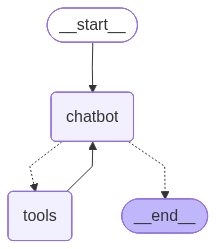

こんにちは！
こんにちは！今日はどんなことをお手伝いできますか？
1たす2は？
1たす2は3です。何か他にお手伝いできることはありますか？
台湾観光について検索結果を教えて

[{"url": "https://www.hankyu-travel.com/guide/taiwan/", "content": "台湾 台北 九份 台中 台南 高雄 グルメ\n\n#### 海外観光ガイド\n\n##### 観光ガイドトップ\n\n 台湾\n 香港\n マカオ\n 韓国\n 中国\n モンゴル\n シンガポール\n マレーシア\n ブルネイ\n タイ\n ベトナム\n カンボジア\n ミャンマー\n ラオス\n フィリピン\n インドネシア\n インド\n ネパール\n スリランカ\n バングラデシュ\n ブータン\n モルディブ\n 中央アジア\n ウズベキスタン\n\n イタリア\n フランス\n ドイツ\n スペイン\n ポルトガル\n イギリス\n スイス\n ギリシャ\n オランダ\n ベルギー\n ルクセンブルク\n マルタ\n モナコ\n アイルランド\n ロシア\n 北欧\n デンマーク\n ノルウェー\n スウェーデン\n フィンランド\n アイスランド\n バルト三国\n エストニア\n ラトビア\n リトアニア\n 東欧・中欧\n オーストリア\n チェコ\n クロアチア\n スロベニア\n ハンガリー\n ポーランド\n ルーマニア\n ブルガリア\n\n アラブ首長国連邦\n トルコ\n ヨルダン\n イスラエル\n イラン\n オマーン\n カタール\n サウジアラビア\n コーカサス\n\n アフリカ\n エジプト\n モロッコ\n チュニジア\n 南アフリカ\n ケニア\n タンザニア\n マダガスカル\n\n アメリカ\n カナダ\n\n メキシコ\n キューバ\n コスタリカ\n コロンビア\n ペルー\n ブラジル\n ボリビア\n アルゼンチン\n チリ\n\n ハワイ\n\n グアム\n サイパン\n パラオ\n\n オーストラリア\n ニュージーランド\n ニューカレドニア\n タヒチ\n フィジー\n\n※写真・イラストはすべてイメージです。ご旅行中に必ずしも同じ角度・高度・天候での風景をご覧いただけるとはかぎりませんのでご了

In [5]:
# 必要なモジュールをインポート
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from typing import Annotated
from typing_extensions import TypedDict
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver


# ===== Stateクラスの定義 =====
class State(TypedDict):
    messages: Annotated[list, add_messages]


# ===== グラフの構築 =====
def build_graph(model_name):
    # ソースコードを記述

    # グラフのインスタンスを作成
    graph_builder = StateGraph(State)

    # 言語モデルの定義
    llm = ChatOpenAI(model_name=model_name)

    # ツールの定義
    tool = TavilySearchResults(max_results=2)
    tools = [tool]

    # ツール定義の紐づけ
    llm_with_tools = llm.bind_tools(tools)

    # チャットボットノードの作成
    def chatbot(state: State):
        return {"messages": [llm_with_tools.invoke(state["messages"])]}

    # グラフにチャットボットノードを追加
    graph_builder.add_node("chatbot", chatbot)

    # ツールノードの作成
    tool_node = ToolNode(tools)

    # グラフにツールノードを追加
    graph_builder.add_node("tools", tool_node)

    # 条件付エッジの作成
    graph_builder.add_conditional_edges(
        "chatbot",
        tools_condition,  # ツール呼出と判断したらツールノードを呼ぶ
    )

    # ツールが呼び出されるたびに、チャットボットに戻って次のステップを決定
    # ツールからチャットボットへの戻りエッジを作成
    graph_builder.add_edge("tools", "chatbot")

    # 開始ノードの指定
    graph_builder.set_entry_point("chatbot")

    # 記憶を持つ実行可能なステートグラフの作成
    memory = MemorySaver()
    graph = graph_builder.compile(checkpointer=memory)

    return graph


# ===== グラフ実行関数 =====
def stream_graph_updates(graph: StateGraph, user_input: str):
    # ソースコードを記述
    events = graph.stream(
        {"messages": [("user", user_input)]},
        {"configurable": {"thread_id": "1"}},
        stream_mode="values",
    )
    # 結果をストリーミングで得る
    for event in events:
        print(event["messages"][-1].content, flush=True)


# ===== メイン実行ロジック =====
# 環境変数の読み込み
load_dotenv("../.env")
os.environ["OPENAI_API_KEY"] = os.environ["API_KEY"]

# モデル名
MODEL_NAME = "gpt-4o-mini"

# グラフの作成
# ソースコードを記述
graph = build_graph(MODEL_NAME)


# グラフの可視化
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


# メインループ
# ソースコードを記述
while True:
    user_input = input("質問:")
    if user_input.strip() == "":
        print("ありがとうございました!")
        break
    stream_graph_updates(graph, user_input)